Reading data

In [15]:
import pandas as pd
df=pd.read_csv('./Car_evaluation_dataset - Car_evaluation_dataset.csv')
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,20795,5048,3,four,large,medium,good
1,5860,3608,2,more,small,low,very good
2,43158,7658,4,two,medium,medium,very good
3,49732,7900,4,more,medium,high,acceptable
4,16284,3670,2,two,medium,high,good


1-Renaming Columns

In [16]:
df=df.rename(columns={'buying':'Buying','maint':'Maintanance','doors':'Num_Doors','persons':'Num_Person','lug_boot':'Luggage_Boot','safety':'Safety','class':'Car_Evaluation'})
df.head()

,Buying,Maintanance,Num_Doors,Num_Person,Luggage_Boot,Safety,Car_Evaluation
0,20795,5048,3,four,large,medium,good
1,5860,3608,2,more,small,low,very good
2,43158,7658,4,two,medium,medium,very good
3,49732,7900,4,more,medium,high,acceptable
4,16284,3670,2,two,medium,high,good


2- datatypes and non null value counts

In [17]:
print(df.dtypes)
print(df.value_counts())
print(df.isna().sum())
df.shape


Buying            int64
Maintanance       int64
Num_Doors         int64
Num_Person          str
Luggage_Boot        str
Safety              str
Car_Evaluation      str
dtype: object
Buying  Maintanance  Num_Doors  Num_Person  Luggage_Boot  Safety  Car_Evaluation
20795   5048         3          four        large         medium  good              1
5860    3608         2          more        small         low     very good         1
43158   7658         4          two         medium        medium  very good         1
49732   7900         4          more        medium        high    acceptable        1
16284   3670         2          two         medium        high    good              1
                                                                                   ..
21371   3414         5          four        small         medium  very good         1
16835   5468         2          four        small         high    very good         1
7049    6417         2          more        small

(256, 7)

3-Unique values in each column


In [18]:
df.nunique()

Buying            256
Maintanance       251
Num_Doors           4
Num_Person          3
Luggage_Boot        3
Safety              3
Car_Evaluation      4
dtype: int64

4-encoding

In [19]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Num_Person']=le.fit_transform(df['Num_Person'])
df['Luggage_Boot']=le.fit_transform(df['Luggage_Boot'])
df['Safety']=le.fit_transform(df['Safety'])
df['Car_Evaluation']=le.fit_transform(df['Car_Evaluation'])
df.head()

,Buying,Maintanance,Num_Doors,Num_Person,Luggage_Boot,Safety,Car_Evaluation
0,20795,5048,3,0,0,2,1
1,5860,3608,2,1,2,1,3
2,43158,7658,4,2,1,2,3
3,49732,7900,4,1,1,0,0
4,16284,3670,2,2,1,0,1


5-Bar plot

<function matplotlib.pyplot.show(close=None, block=None)>

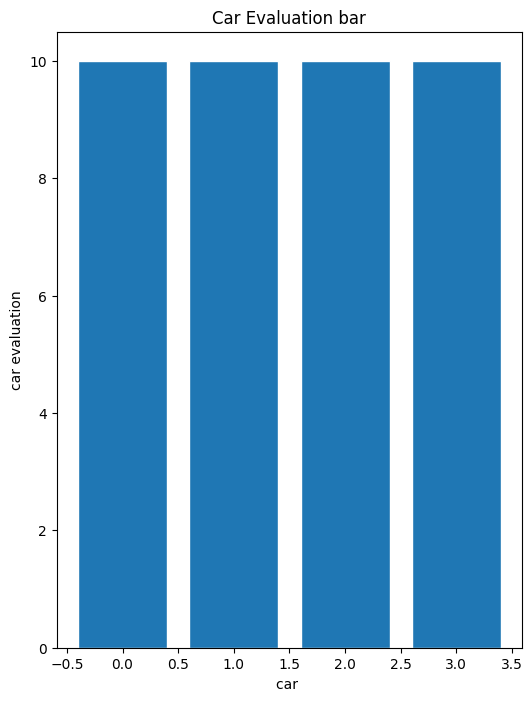

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,8))
plt.bar(df['Car_Evaluation'], edgecolor='white',height=10)
plt.xlabel('car ')
plt.ylabel('car evaluation')
plt.title('Car Evaluation bar')
plt.show

Splitting data into test split

In [21]:
from sklearn.model_selection import train_test_split
X=df.drop('Car_Evaluation',axis=1)
Y=df['Car_Evaluation']
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=42)


Feature Svcalling first

In [22]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


Part 2: Classification

1:K-Nearest Neigbors

In [23]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(5) #k value =5
knn.fit(X_train_scaled, Y_train)
y_pred_knn = knn.predict(X_test_scaled)


2:LinearRegression
It was a classification problem so cannot apply linear regression directly

In [24]:
# from sklearn.linear_model import LinearRegression
# l_model=LinearRegression()
# l_model.fit(X_train_scaled, Y_train)
# Y_predict_linear=l_model.predict(X_test_scaled)

3:Logistic Regression

In [25]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train_scaled, Y_train)
y_pred_logistic=model.predict(X_test_scaled)

Evaluating F1 score, accuracy, precession,Recall

1 accuracy score:

In [26]:
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score
# print(f"Knn model accuracy: {accuracy_score(Y_test,y_pred_knn)}\nLinear model accuracy: {accuracy_score(Y_test,Y_predict_linear)}\nLogistic  model accuracy: {accuracy_score(Y_test,y_pred_logistic)}")
print(f"Knn model accuracy: {accuracy_score(Y_test,y_pred_knn)}\n\nLogistic  model accuracy: {accuracy_score(Y_test,y_pred_logistic)}")


Knn model accuracy: 0.18181818181818182

Logistic  model accuracy: 0.23376623376623376


2-f1 score

In [27]:
print(f"Knn model f1 score: {f1_score(Y_test,y_pred_knn)}\nLogistic  model f1 score: {f1_score(Y_test,y_pred_logistic)}")


ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].

3- Precision

In [ ]:
print(f"knn model precision: {precision_score(Y_test,y_pred_knn)}\nlogistic   model precision: {precision_score(Y_test,y_pred_logistic)}")


ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].

4-Recall score

In [ ]:
print(f"Knn model Recall Score: {recall_score(Y_test,y_pred_knn)}\n\nLogistic  model Recall Score: {recall_score(Y_test,y_pred_logistic)}")


ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].